In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load dataset
df = pd.read_csv("train.csv")

print(df.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

In [3]:
# Dimensions
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Basic information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe(include="all"))


Shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Ord

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique values:")
print(df.nunique())


Number of rows: 9800
Number of columns: 18

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate rows:
0

Unique values:
Row ID           9800
Order ID         4922
Order Date       1230
Ship Date        1326
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              529
State              49
Postal Code       626
Region              4
Product ID       1861
Category            3
Sub-Category       17
Product Name     1849
Sales            5757
dtype: int64


In [5]:
df = df.drop_duplicates()


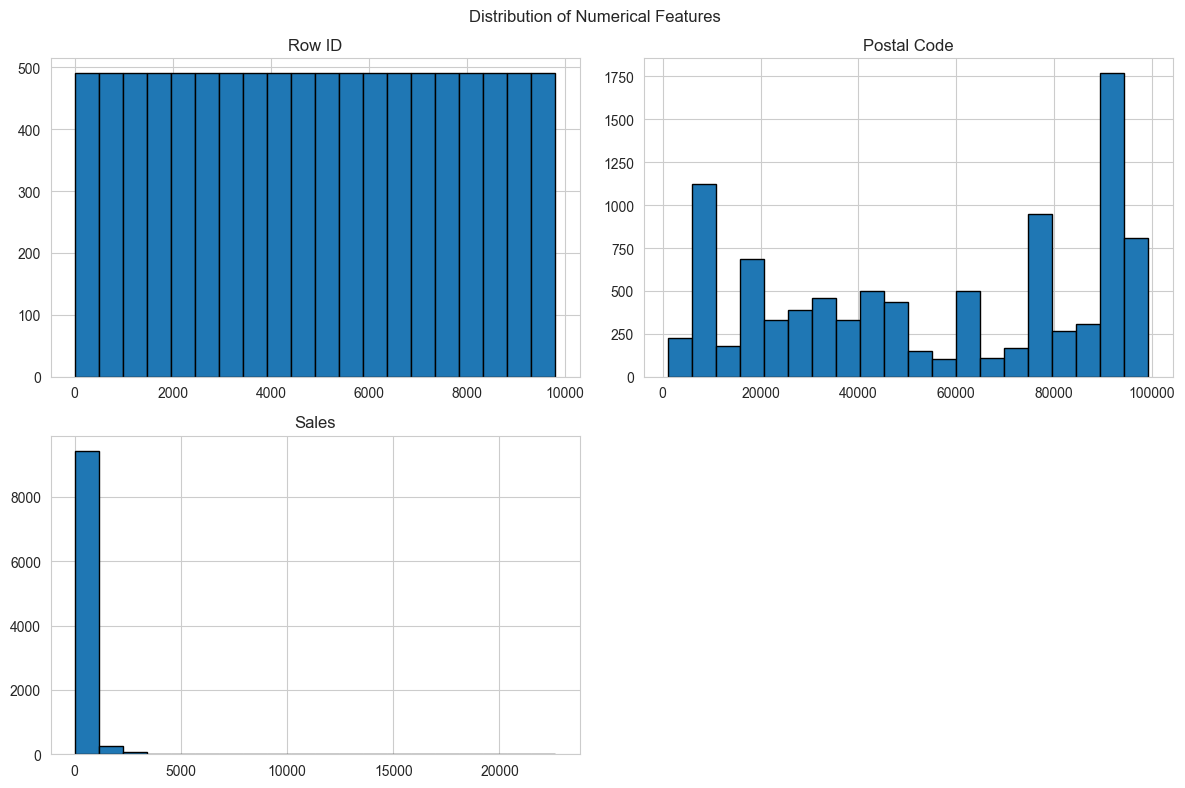

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(
    figsize=(12, 8),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()


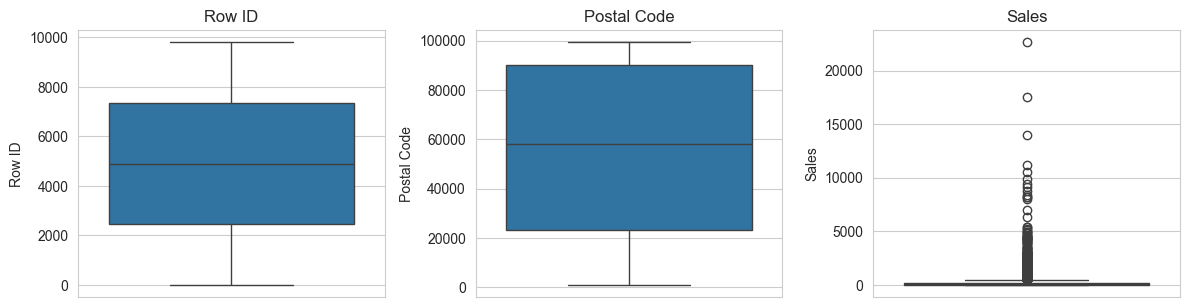

In [7]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


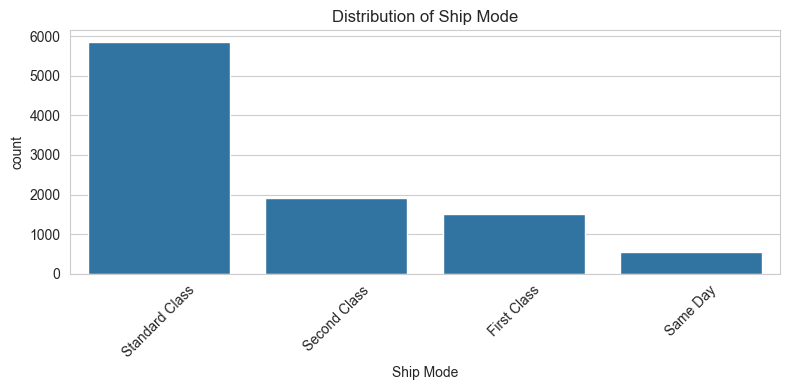

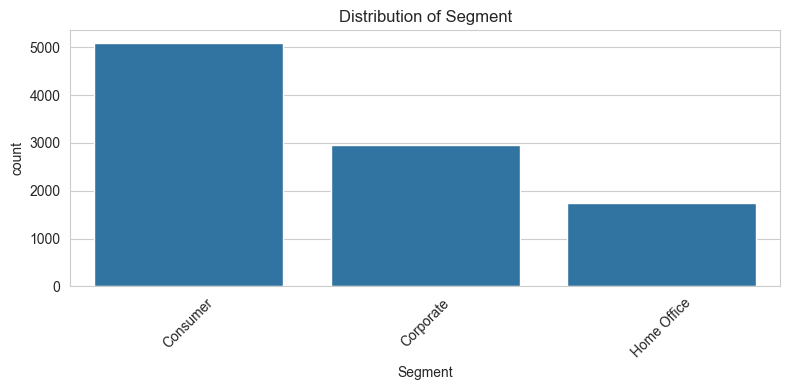

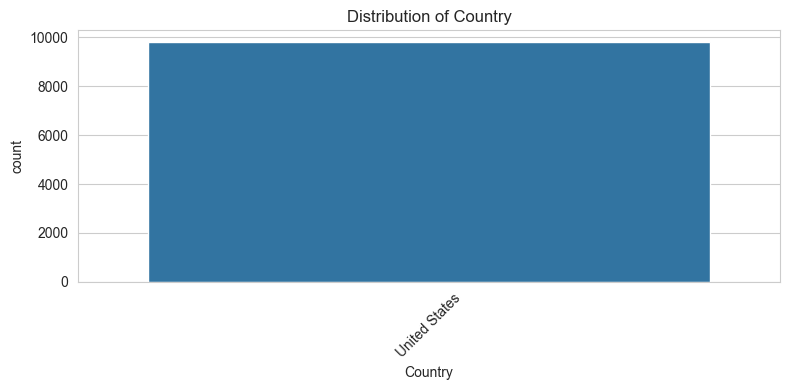

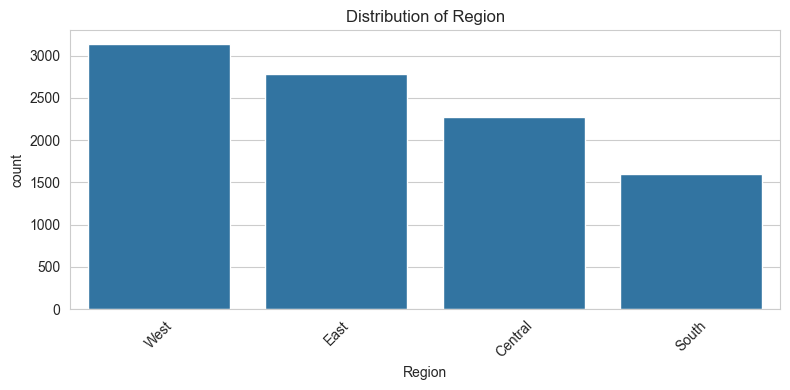

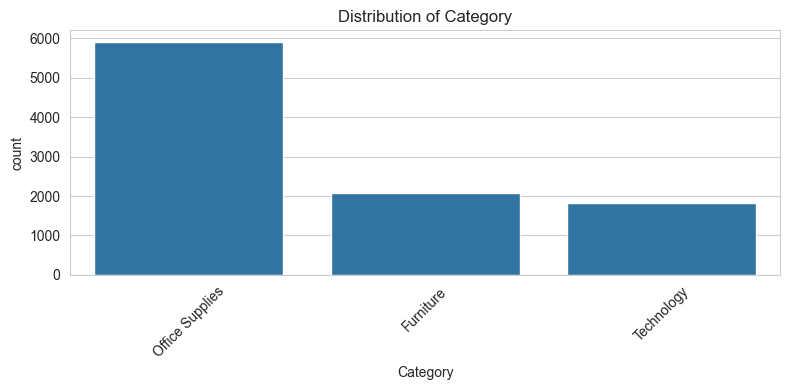

In [8]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    if df[col].nunique() <= 15:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f"Distribution of {col}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


               Row ID  Postal Code     Sales
Row ID       1.000000     0.013645  0.001151
Postal Code  0.013645     1.000000 -0.024067
Sales        0.001151    -0.024067  1.000000


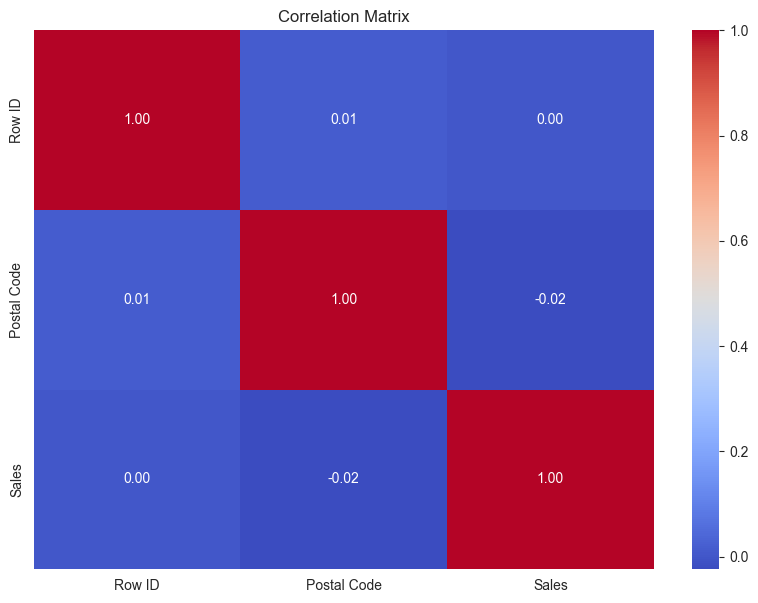

In [9]:
correlation = df[numeric_cols].corr()

print(correlation)

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()


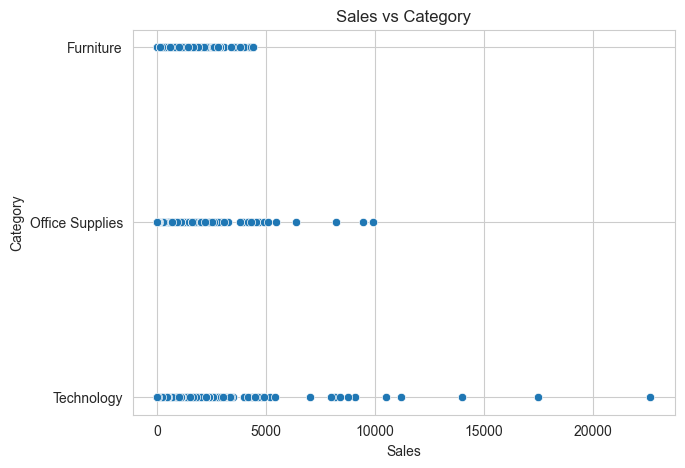

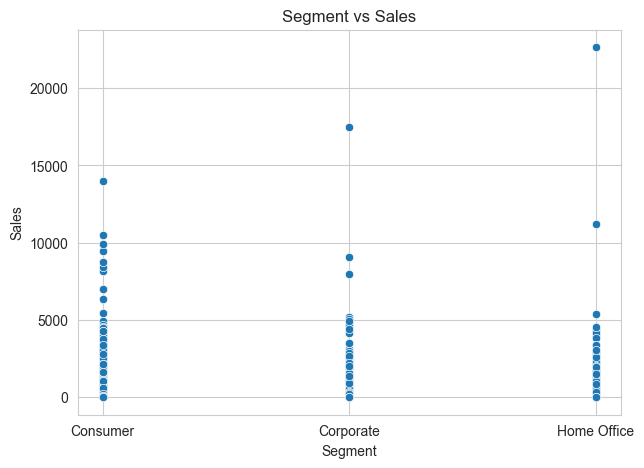

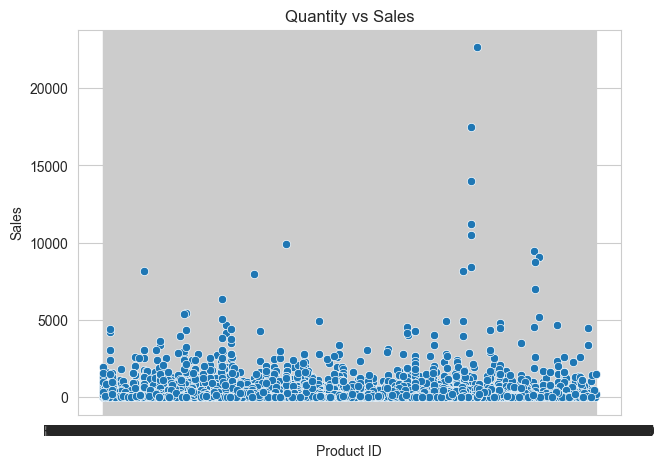

In [16]:
# Sales vs Profit
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Sales", y="Category")
plt.title("Sales vs Category")
plt.show()

# Discount vs Profit
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Segment", y="Sales")
plt.title("Segment vs Sales")
plt.show()

# Quantity vs Sales
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Product ID", y="Sales")
plt.title("Product ID vs Sales")
plt.show()


In [18]:
print("Sales statistics:")
print(df["Sales"].describe())

print("\nPOSTAL CODE statistics:")
print(df["Postal Code"].describe())


Sales statistics:
count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

POSTAL CODE statistics:
count     9789.000000
mean     55273.322403
std      32041.223413
min       1040.000000
25%      23223.000000
50%      58103.000000
75%      90008.000000
max      99301.000000
Name: Postal Code, dtype: float64


In [20]:
print(df.groupby("Category")["Sales"].sum())

print(df.groupby("Category")["Postal Code"].sum())


Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64
Category
Furniture          115537643.0
Office Supplies    324855035.0
Technology         100677875.0
Name: Postal Code, dtype: float64


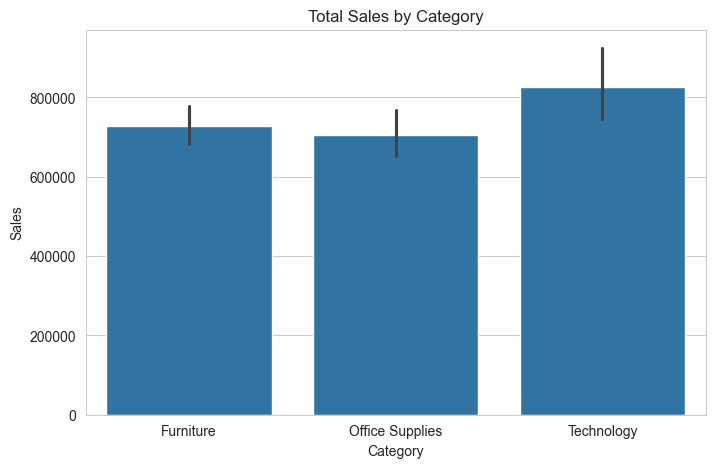

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Category", y="Sales", estimator=sum)
plt.title("Total Sales by Category")
plt.show()


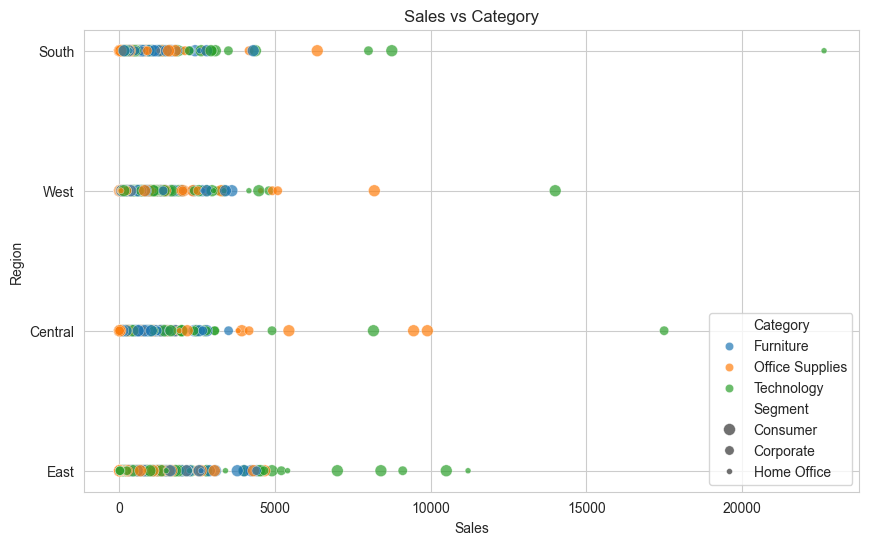

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Region",
    hue="Category",
    size="Segment",
    alpha=0.7
)

plt.title("Sales vs Category")
plt.show()


In [ ]:
print("Total Sales:", df["Sales"].sum())
print("Total Category:", df["Category"].sum())
print("Average Sales:", df["Sales"].mean())
print("Average Category:", df["Category"].mean())

print("\nSales by Category:")
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

print("\nProfit by Category:")
print(df.groupby("Category")["Profit"].sum().sort_values(ascending=False))

print("\nSales by Region:")
print(df.groupby("Region")["Sales"].sum().sort_values(ascending=False))

print("\nProfit by Region:")
print(df.groupby("Region")["Profit"].sum().sort_values(ascending=False))

